In [4]:
from entsoe import EntsoePandasClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# Konfiguration
api_key = 'bb3e41e9-4d6f-43da-be8e-d7d47fb6e846'
client = EntsoePandasClient(api_key=api_key)
country_code = '10Y1001A1001A83F'  # Deutschland




STROMPREIS-STREAM GESTARTET
Update-Intervall: 60 Sekunden
Land: Deutschland (DE)
Chart-Intervall: 1 Stunde Kerzen

WICHTIG:
- Der Chart erscheint nach dem ersten Datenabruf
- ENTSO-E liefert KEINE sekundlichen/5-Sekunden Daten!
- Day-Ahead: Stuendliche Preise (1x pro Tag aktualisiert)
- Intraday: 15-Minuten bis Stunden-Preise

Druecke Ctrl+C zum Beenden.

Starte ersten Datenabruf...

[14:16:12] Rufe Daten ab...
   Zeitraum: 2025-12-07 14:16 bis 2025-12-08 14:16
   Versuche Day-Ahead Preise...
   Day-Ahead fehlgeschlagen: 
   Versuche Intraday Preise...
   Intraday fehlgeschlagen: EntsoePandasClient.query_intraday_prices() missing 1 required positional argument: 'sequence'

!!! FEHLER: Keine Daten empfangen !!!
    Pruefen Sie:
    1. Ist der API-Key korrekt?
    2. Haben Sie Internet-Verbindung?
    3. Ist die ENTSO-E API erreichbar?

Chart-Fenster sollte jetzt sichtbar sein!


C:\Users\bedla\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


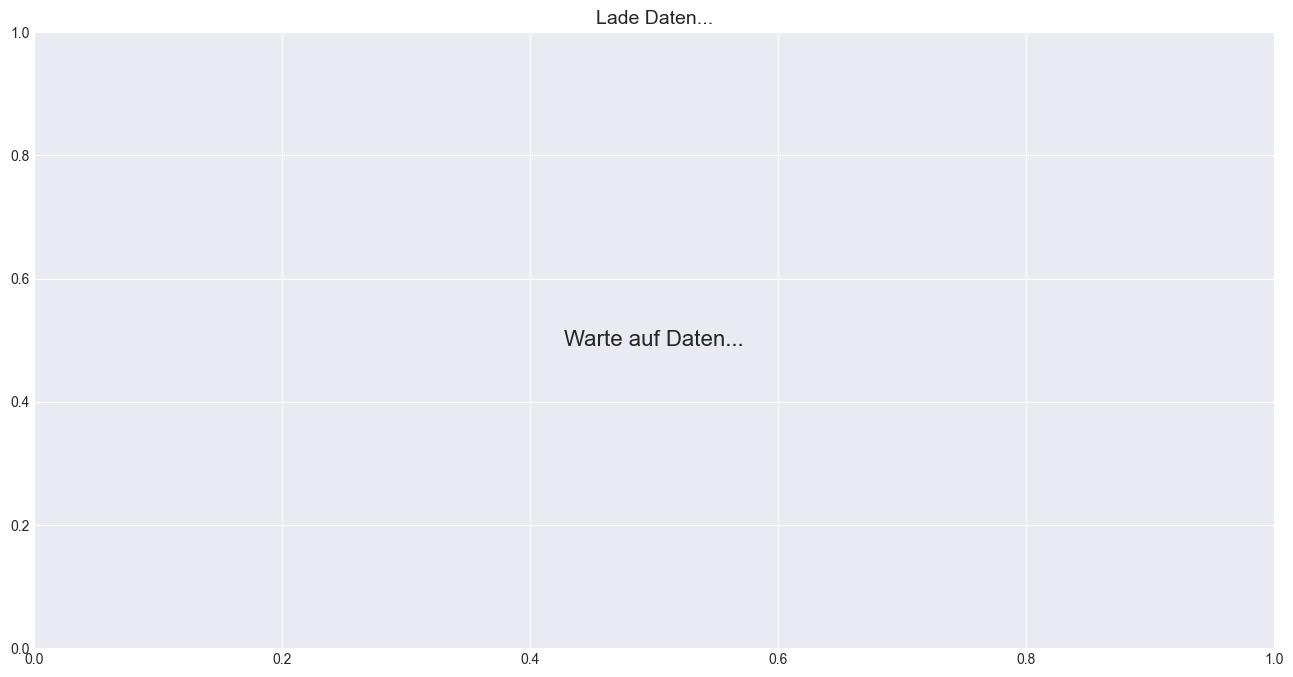

In [5]:
from entsoe import EntsoePandasClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from datetime import datetime, timedelta
import threading

# Konfiguration
api_key = 'bb3e41e9-4d6f-43da-be8e-d7d47fb6e846'  # HIER DEINEN API-KEY EINTRAGEN!
client = EntsoePandasClient(api_key=api_key)
country_code = '10Y1001A1001A83F'  # Deutschland

# Daten-Container
all_prices = pd.DataFrame()
last_prices = pd.DataFrame()
update_lock = threading.Lock()

def get_latest_prices():
    """Holt die neuesten Preise"""
    end = pd.Timestamp.now(tz='Europe/Berlin')
    start = end - timedelta(hours=24)
    
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Rufe Daten ab...")
    print(f"   Zeitraum: {start.strftime('%Y-%m-%d %H:%M')} bis {end.strftime('%Y-%m-%d %H:%M')}")
    
    try:
        print("   Versuche Day-Ahead Preise...")
        prices = client.query_day_ahead_prices(country_code, start=start, end=end)
        print(f"   SUCCESS! {len(prices)} Day-Ahead Datenpunkte empfangen")
        return prices
    except Exception as e:
        print(f"   Day-Ahead fehlgeschlagen: {str(e)[:100]}")
        
        try:
            print("   Versuche Intraday Preise...")
            prices = client.query_intraday_prices(country_code, start=start, end=end)
            print(f"   SUCCESS! {len(prices)} Intraday Datenpunkte empfangen")
            return prices
        except Exception as e2:
            print(f"   Intraday fehlgeschlagen: {str(e2)[:100]}")
            return None

def print_new_prices(new_prices, old_prices):
    """Zeigt neue Preise in der Konsole an"""
    if new_prices is None or len(new_prices) == 0:
        return
    
    if old_prices is None or len(old_prices) == 0:
        # Erste Abfrage - zeige letzte 10 Preise
        print("\n" + "="*70)
        print("INITIALE PREISDATEN (letzte 10 Eintraege):")
        print("="*70)
        for ts, price in new_prices.tail(10).items():
            print(f"  {ts.strftime('%Y-%m-%d %H:%M:%S')} | {price:>8.2f} EUR/MWh")
        return
    
    # Finde neue Einträge
    new_timestamps = set(new_prices.index) - set(old_prices.index)
    
    if len(new_timestamps) > 0:
        print("\n" + "="*70)
        print(f"*** NEUE PREISE ({len(new_timestamps)} Eintraege) ***")
        print("="*70)
        for ts in sorted(new_timestamps):
            price = new_prices[ts]
            # Vergleich mit vorherigem Preis
            prev_idx = new_prices.index.get_loc(ts) - 1
            if prev_idx >= 0:
                prev_price = new_prices.iloc[prev_idx]
                diff = price - prev_price
                arrow = "UP" if diff > 0 else "DOWN" if diff < 0 else "--"
                diff_str = f"{diff:+.2f}" if diff != 0 else "0.00"
                print(f"  {ts.strftime('%Y-%m-%d %H:%M:%S')} | {price:>8.2f} EUR/MWh [{arrow}] ({diff_str})")
            else:
                print(f"  {ts.strftime('%Y-%m-%d %H:%M:%S')} | {price:>8.2f} EUR/MWh")
        
        # Zeige aktuelle Statistiken
        print("-"*70)
        print(f"  Aktuell: {new_prices.iloc[-1]:.2f} EUR/MWh")
        print(f"  Min (24h): {new_prices.tail(24).min():.2f} EUR/MWh")
        print(f"  Max (24h): {new_prices.tail(24).max():.2f} EUR/MWh")
        print(f"  Durchschnitt (24h): {new_prices.tail(24).mean():.2f} EUR/MWh")
        print("="*70)
    else:
        timestamp = datetime.now().strftime('%H:%M:%S')
        print(f"\n[{timestamp}] Keine neuen Daten - warte auf Update...")

def prepare_candles(prices, interval='1H'):
    """Bereitet Kerzendaten aus den Preisen vor"""
    if prices is None or len(prices) == 0:
        return None
    
    df = pd.DataFrame(prices, columns=['price'])
    df.index = pd.to_datetime(df.index)
    
    candles = df.resample(interval).agg({
        'price': ['first', 'max', 'min', 'last', 'count']
    })
    candles.columns = ['open', 'high', 'low', 'close', 'count']
    candles = candles[candles['count'] > 0]
    
    return candles

def plot_candlestick(ax, candles):
    """Plottet Kerzenchart"""
    ax.clear()
    
    if candles is None or len(candles) == 0:
        ax.text(0.5, 0.5, 'Warte auf Daten...', 
                ha='center', va='center', transform=ax.transAxes, fontsize=16)
        ax.set_title('Lade Daten...', fontsize=14)
        return
    
    # Kerzen zeichnen
    for idx, (timestamp, row) in enumerate(candles.iterrows()):
        color = 'green' if row['close'] >= row['open'] else 'red'
        
        # Docht (high-low)
        ax.plot([idx, idx], [row['low'], row['high']], 
                color='black', linewidth=1.5)
        
        # Körper (open-close)
        height = abs(row['close'] - row['open'])
        if height < 0.01:  # Minimale Höhe für Doji
            height = candles['high'].max() * 0.002
        bottom = min(row['open'], row['close'])
        ax.bar(idx, height, bottom=bottom, color=color, 
               alpha=0.8, width=0.7, edgecolor='black', linewidth=0.5)
    
    # Statistiken im Titel
    current_price = candles['close'].iloc[-1]
    min_price = candles['low'].min()
    max_price = candles['high'].max()
    
    ax.set_ylabel('Preis (EUR/MWh)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Zeit', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Strompreise Deutschland | '
        f'Aktuell: {current_price:.2f} EUR/MWh | '
        f'Min: {min_price:.2f} | Max: {max_price:.2f}\n'
        f'{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        fontsize=12, fontweight='bold', pad=15
    )
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # X-Achse formatieren
    if len(candles) > 0:
        n_ticks = min(12, len(candles))
        tick_positions = list(range(0, len(candles), max(1, len(candles) // n_ticks)))
        tick_labels = [candles.index[i].strftime('%d.%m %H:%M') for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    plt.tight_layout()

def update_plot(frame):
    """Update-Funktion für Animation"""
    global all_prices, last_prices
    
    with update_lock:
        prices = get_latest_prices()
        
        if prices is not None:
            print_new_prices(prices, last_prices)
            last_prices = all_prices.copy() if len(all_prices) > 0 else None
            all_prices = prices
        else:
            print("\n!!! FEHLER: Keine Daten empfangen !!!")
            print("    Pruefen Sie:")
            print("    1. Ist der API-Key korrekt?")
            print("    2. Haben Sie Internet-Verbindung?")
            print("    3. Ist die ENTSO-E API erreichbar?")
        
        candles = prepare_candles(all_prices, interval='1H')
        plot_candlestick(ax, candles)

# Plot Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(16, 8))

print("\n" + "="*70)
print("STROMPREIS-STREAM GESTARTET")
print("="*70)
print("Update-Intervall: 60 Sekunden")
print("Land: Deutschland (DE)")
print("Chart-Intervall: 1 Stunde Kerzen")
print("="*70)
print("\nWICHTIG:")
print("- Der Chart erscheint nach dem ersten Datenabruf")
print("- ENTSO-E liefert KEINE sekundlichen/5-Sekunden Daten!")
print("- Day-Ahead: Stuendliche Preise (1x pro Tag aktualisiert)")
print("- Intraday: 15-Minuten bis Stunden-Preise")
print("="*70)
print("\nDruecke Ctrl+C zum Beenden.\n")

# Erster Datenabruf VOR Animation-Start
print("Starte ersten Datenabruf...")
update_plot(0)

# Animation starten - Variable MUSS gespeichert werden!
anim = FuncAnimation(fig, update_plot, interval=60000, cache_frame_data=False)

print("\nChart-Fenster sollte jetzt sichtbar sein!")
plt.show()


STROMPREIS-STREAM GESTARTET
WICHTIG: Ersetze 'MeinToken' mit deinem echten API-Key!
         Registrierung: https://transparency.entsoe.eu/
Update-Intervall: 60 Sekunden
Land: Deutschland (DE)

Starte ersten Datenabruf (kann 5-10 Sekunden dauern)...

[14:58:42] DATENABRUF GESTARTET
Zeitraum: 2025-12-06 14:58 bis 2025-12-08 14:58
API-Key: bb3e41e9-4... (erste 10 Zeichen)

[1/3] Versuche Day-Ahead Preise...
      FEHLER: 
      Details: Traceback (most recent call last):
  File "C:\Users\bedla\AppData\Local\Temp\ipykernel_22348\1042681915.py", line 32, in get_latest_prices
    prices = client.query_day_ahead_prices(country_code, star

[2/3] Versuche Intraday Preise...
      FEHLER: EntsoePandasClient.query_intraday_prices() missing 1 required positional argument: 'sequence'
      Details: Traceback (most recent call last):
  File "C:\Users\bedla\AppData\Local\Temp\ipykernel_22348\1042681915.py", line 44, in get_latest_prices
    prices = client.query_intraday_prices(country_code, start


C:\Users\bedla\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


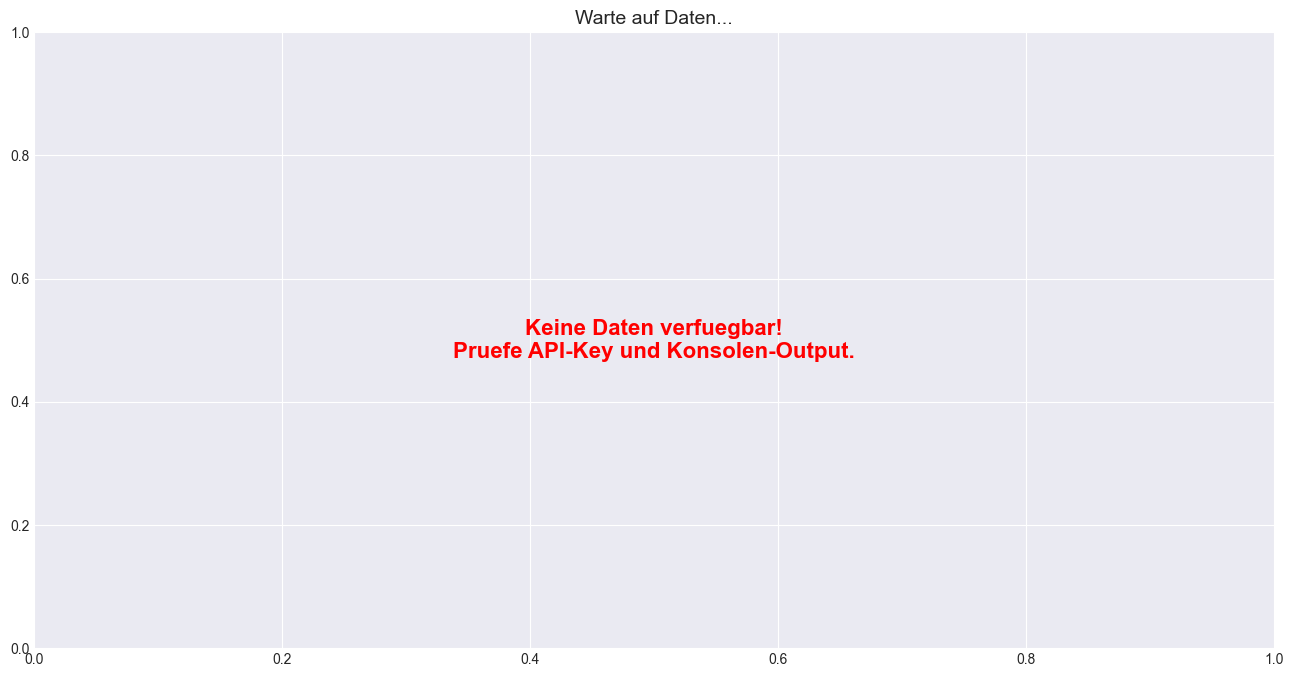

In [13]:
from entsoe import EntsoePandasClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from datetime import datetime, timedelta
import traceback

# Konfiguration
api_key = 'bb3e41e9-4d6f-43da-be8e-d7d47fb6e846'  # HIER DEINEN API-KEY EINTRAGEN!
client = EntsoePandasClient(api_key=api_key)
country_code = '10Y1001A1001A83F'  # Deutschland

# Daten-Container
all_prices = pd.DataFrame()
last_prices = pd.DataFrame()
last_successful_fetch = None

def get_latest_prices():
    """Holt die neuesten Preise mit ausführlichem Error-Logging"""
    end = pd.Timestamp.now(tz='Europe/Berlin')
    start = end - timedelta(hours=48)
    
    print(f"\n{'='*70}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] DATENABRUF GESTARTET")
    print(f"{'='*70}")
    print(f"Zeitraum: {start.strftime('%Y-%m-%d %H:%M')} bis {end.strftime('%Y-%m-%d %H:%M')}")
    print(f"API-Key: {api_key[:10]}... (erste 10 Zeichen)")
    
    # Versuch 1: Day-Ahead Preise
    try:
        print("\n[1/3] Versuche Day-Ahead Preise...")
        prices = client.query_day_ahead_prices(country_code, start=start, end=end)
        print(f"      SUCCESS! {len(prices)} Datenpunkte empfangen")
        print(f"      Erster Preis: {prices.iloc[0]:.2f} EUR/MWh um {prices.index[0]}")
        print(f"      Letzter Preis: {prices.iloc[-1]:.2f} EUR/MWh um {prices.index[-1]}")
        return prices
    except Exception as e:
        print(f"      FEHLER: {str(e)}")
        print(f"      Details: {traceback.format_exc()[:200]}")
    
    # Versuch 2: Intraday Preise
    try:
        print("\n[2/3] Versuche Intraday Preise...")
        prices = client.query_intraday_prices(country_code, start=start, end=end)
        print(f"      SUCCESS! {len(prices)} Datenpunkte empfangen")
        print(f"      Erster Preis: {prices.iloc[0]:.2f} EUR/MWh um {prices.index[0]}")
        print(f"      Letzter Preis: {prices.iloc[-1]:.2f} EUR/MWh um {prices.index[-1]}")
        return prices
    except Exception as e:
        print(f"      FEHLER: {str(e)}")
        print(f"      Details: {traceback.format_exc()[:200]}")
    
    # Versuch 3: Längerer Zeitraum für Day-Ahead
    try:
        print("\n[3/3] Versuche Day-Ahead mit längerem Zeitraum...")
        start_long = end - timedelta(days=7)
        prices = client.query_day_ahead_prices(country_code, start=start_long, end=end)
        print(f"      SUCCESS! {len(prices)} Datenpunkte empfangen")
        print(f"      Erster Preis: {prices.iloc[0]:.2f} EUR/MWh um {prices.index[0]}")
        print(f"      Letzter Preis: {prices.iloc[-1]:.2f} EUR/MWh um {prices.index[-1]}")
        return prices
    except Exception as e:
        print(f"      FEHLER: {str(e)}")
    
    print("\n!!! ALLE VERSUCHE FEHLGESCHLAGEN !!!")
    print("Mögliche Ursachen:")
    print("  1. API-Key ist ungültig oder abgelaufen")
    print("  2. Keine Internetverbindung")
    print("  3. ENTSO-E Server nicht erreichbar")
    print("  4. Rate-Limit erreicht")
    return None

def print_latest_price(prices):
    """Zeigt den aktuellsten verfügbaren Preis prominent an"""
    if prices is None or len(prices) == 0:
        return
    
    latest = prices.iloc[-1]
    latest_time = prices.index[-1]
    
    print(f"\n{'*'*70}")
    print(f"{'*'*70}")
    print(f"*** AKTUELLSTER VERFUEGBARER PREIS ***")
    print(f"{'*'*70}")
    print(f"  PREIS: {latest:.2f} EUR/MWh")
    print(f"  ZEIT:  {latest_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  ALTER: {(pd.Timestamp.now(tz='Europe/Berlin') - latest_time).total_seconds() / 60:.0f} Minuten")
    print(f"{'*'*70}")
    print(f"{'*'*70}\n")

def prepare_candles(prices, interval='1H'):
    """Bereitet Kerzendaten aus den Preisen vor"""
    if prices is None or len(prices) == 0:
        return None
    
    df = pd.DataFrame(prices, columns=['price'])
    df.index = pd.to_datetime(df.index)
    
    candles = df.resample(interval).agg({
        'price': ['first', 'max', 'min', 'last', 'count']
    })
    candles.columns = ['open', 'high', 'low', 'close', 'count']
    candles = candles[candles['count'] > 0]
    
    return candles

def plot_candlestick(ax, candles, raw_prices=None):
    """Plottet Kerzenchart"""
    ax.clear()
    
    if candles is None or len(candles) == 0:
        # Zeige zumindest Info-Text wenn keine Daten
        if raw_prices is not None and len(raw_prices) > 0:
            latest = raw_prices.iloc[-1]
            latest_time = raw_prices.index[-1]
            ax.text(0.5, 0.5, 
                    f'Letzter verfuegbarer Preis:\n{latest:.2f} EUR/MWh\n{latest_time.strftime("%Y-%m-%d %H:%M:%S")}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=20, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            ax.text(0.5, 0.5, 'Keine Daten verfuegbar!\nPruefe API-Key und Konsolen-Output.', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=16, color='red', fontweight='bold')
        ax.set_title('Warte auf Daten...', fontsize=14)
        return
    
    # Kerzen zeichnen
    for idx, (timestamp, row) in enumerate(candles.iterrows()):
        color = 'green' if row['close'] >= row['open'] else 'red'
        
        # Docht (high-low)
        ax.plot([idx, idx], [row['low'], row['high']], 
                color='black', linewidth=1.5)
        
        # Körper (open-close)
        height = abs(row['close'] - row['open'])
        if height < 0.01:
            height = candles['high'].max() * 0.002
        bottom = min(row['open'], row['close'])
        ax.bar(idx, height, bottom=bottom, color=color, 
               alpha=0.8, width=0.7, edgecolor='black', linewidth=0.5)
    
    # Statistiken
    current_price = candles['close'].iloc[-1]
    min_price = candles['low'].min()
    max_price = candles['high'].max()
    avg_price = candles['close'].mean()
    
    ax.set_ylabel('Preis (EUR/MWh)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Zeit', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Strompreise Deutschland\n'
        f'Aktuell: {current_price:.2f} | Min: {min_price:.2f} | Max: {max_price:.2f} | Avg: {avg_price:.2f} EUR/MWh\n'
        f'{datetime.now().strftime("%Y-%m-%d %H:%M:%S")} | {len(candles)} Kerzen',
        fontsize=11, fontweight='bold', pad=15
    )
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # X-Achse formatieren
    if len(candles) > 0:
        n_ticks = min(12, len(candles))
        tick_positions = list(range(0, len(candles), max(1, len(candles) // n_ticks)))
        tick_labels = [candles.index[i].strftime('%d.%m %H:%M') for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    plt.tight_layout()

def update_plot(frame):
    """Update-Funktion für Animation"""
    global all_prices, last_prices, last_successful_fetch
    
    prices = get_latest_prices()
    
    if prices is not None:
        all_prices = prices
        last_successful_fetch = datetime.now()
        print_latest_price(prices)
        
        # Zeige auch die letzten 5 Preise
        print("Letzte 5 Preise:")
        for ts, price in prices.tail(5).items():
            print(f"  {ts.strftime('%Y-%m-%d %H:%M:%S')} | {price:>8.2f} EUR/MWh")
    else:
        print("\n!!! KEINE DATEN EMPFANGEN !!!")
        if last_successful_fetch:
            print(f"Letzter erfolgreicher Abruf: {last_successful_fetch.strftime('%H:%M:%S')}")
    
    candles = prepare_candles(all_prices, interval='1H')
    plot_candlestick(ax, candles, all_prices)
    
    # Force redraw
    plt.draw()

# Plot Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(16, 8))

print("\n" + "="*70)
print("STROMPREIS-STREAM GESTARTET")
print("="*70)
print("WICHTIG: Ersetze 'MeinToken' mit deinem echten API-Key!")
print("         Registrierung: https://transparency.entsoe.eu/")
print("="*70)
print("Update-Intervall: 60 Sekunden")
print("Land: Deutschland (DE)")
print("="*70)

# Erster Datenabruf
print("\nStarte ersten Datenabruf (kann 5-10 Sekunden dauern)...")
update_plot(0)

# Animation starten
anim = FuncAnimation(fig, update_plot, interval=60000, cache_frame_data=False)

print("\n>>> Chart-Fenster sollte jetzt sichtbar sein! <<<")
print(">>> Falls nicht: Prüfe die Fehlermeldungen oben <<<\n")
plt.show()

In [10]:
from entsoe import EntsoePandasClient
import pandas as pd
from datetime import datetime, timedelta
import sys

print("=== ENTSO-E API TEST (FIXED VERSION) ===")
print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

api_key = 'bb3e41e9-4d6f-43da-be8e-d7d47fb6e846'
country_code = '10Y1001A1001A83F'  # DE-LU (Deutschland) [web:73]

try:
    client = EntsoePandasClient(api_key=api_key)
    print("✓ Client OK\n")

    # Sicherer Zeitraum: Letzte 24h + morgen (Day-Ahead)
    end = pd.Timestamp.now(tz='Europe/Berlin') + timedelta(days=1)
    start = end - timedelta(days=2)

    print(f"Zeitraum: {start.strftime('%Y-%m-%d')} → {end.strftime('%Y-%m-%d')}")

    # 1. Day-Ahead mit expliziten Parametern
    print("\n1. DAY-AHEAD PREISE...")
    try:
        prices_da = client.query_day_ahead_prices(
            country_code,
            start=start,
            end=end
        )
        print(f"   ✓ {len(prices_da)} Preise: {prices_da.iloc[-1]:.2f}€ am {prices_da.index[-1]}")
    except Exception as e:
        print(f"   ✗ {str(e)[:120]}")

    # 2. Intraday mit sequence=1 (Continuous)
    print("\n2. INTRADAY PREISE (sequence=1)...")
    try:
        prices_id = client.query_intraday_prices(
            country_code,
            start=start,
            end=end,
            sequence=1  # FIX: Required parameter!
        )
        print(f"   ✓ {len(prices_id)} Preise: {prices_id.iloc[-1]:.2f}€ am {prices_id.index[-1]}")
    except Exception as e:
        print(f"   ✗ {str(e)[:120]}")

    # 3. Day-Ahead + Intraday Kombi (häufigste Kombi)
    print("\n3. DAY-AHEAD + INTRADAY...")
    try:
        all_prices = client.query_day_ahead_prices(country_code, start=start, end=end)
        print(f"   ✓ DAY-AHEAD OK ({len(all_prices)} Punkte)")
    except:
        try:
            all_prices = client.query_intraday_prices(country_code, start=start, end=end, sequence=1)
            print(f"   ✓ INTRADAY OK ({len(all_prices)} Punkte)")
        except Exception as e:
            print(f"   ✗ BEIDE FEHLER: {str(e)[:100]}")

    # 4. Zeige Daten
    if 'all_prices' in locals() and len(all_prices) > 0:
        print(f"\n✓ LETZTE 5 PREISE:")
        print(all_prices.tail().round(2).to_string())

except Exception as e:
    print(f"✗ FATALE FEHLER: {str(e)}")
    print("\n🔧 FIX:")
    print("pip install --upgrade entsoe-py")
    print("Falls immer noch leer: API-Key neu auf https://transparency.entsoe.eu/ [web:76]")

print("\n=== TEST ENDE ===")


=== ENTSO-E API TEST (FIXED VERSION) ===
Start: 2025-12-08 14:23:51

✓ Client OK

Zeitraum: 2025-12-07 → 2025-12-09

1. DAY-AHEAD PREISE...
   ✗ 

2. INTRADAY PREISE (sequence=1)...
   ✗ 

3. DAY-AHEAD + INTRADAY...
   ✗ BEIDE FEHLER: 

=== TEST ENDE ===


In [11]:
import entsoe
import pandas as pd
from datetime import datetime, timedelta

print(f"entsoe-py Version: {entsoe.__version__}")
print("Verfügbare Länder:", list(entsoe.mappings.psr_type_mapping.keys())[:5])

# NEUER API-KEY HIER!
NEW_API_KEY = 'DEIN-NEUER-KEY-HIER'
country_code = 'DE_LU'  # Alternativ: String statt EIC-Code versuchen [web:73]

try:
    client = entsoe.EntsoePandasClient(NEW_API_KEY)

    # Minimal-Test: NUR heute + morgen
    end = pd.Timestamp.now(tz='Europe/Berlin') + timedelta(days=1)
    start = pd.Timestamp.now(tz='Europe/Berlin').normalize()

    print(f"\nTest mit: {start.date()} → {end.date()}")

    # TRY verschiedene Methoden
    prices = client.query_day_ahead_prices(country_code, start, end)
    print(f"✓ DAY-AHEAD: {len(prices)} Preise erhalten!")
    print(prices.tail(3))

except Exception as e:
    print(f"FEHLER: {e}")
    print("\n→ 99% API-KEY Problem!")


entsoe-py Version: 0.7.8


AttributeError: module 'entsoe.mappings' has no attribute 'psr_type_mapping'